## Load packages and define functions

In [46]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

In [47]:
def elec(tech=None):
    if not tech is None:
        return f'Secondary Energy|Electricity|{tech}'
    else:
        return 'Secondary Energy|Electricity'

In [48]:
REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')
REMIND_RMAP

RegionMapping(model_name='REMIND_2.1', iso_to_region=ISO
ABW    LAM
AFG    OAS
AGO    SSA
AIA    LAM
ALA    EUR
      ... 
WSM    OAS
YEM    MEA
ZAF    SSA
ZMB    SSA
ZWE    SSA
Name: REMIND_2.1.REGION, Length: 246, dtype: object, region_names={'LAM': 'Latin America and the Caribbean', 'OAS': 'Other Asia', 'SSA': 'Sub-Saharan Africa', 'EUR': 'EU28', 'NEU': 'Europe (non-EU28)', 'MEA': 'Middle East and North Africa', 'REF': 'Russia', 'CAZ': 'Canada, Australia and New Zealand', 'CHA': 'China', 'IND': 'India', 'JPN': 'Japan', 'USA': 'USA'})

In [49]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",#"EU27",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

IKEA_ISOS.sort()

## Load data

In [50]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [51]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [52]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [53]:
NPE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Country assessment"

)

NPE_PATH: os.PathLike = BOX_MOUNT_PATH / NPE_PATH

In [54]:
# input_data = pyam.IamDataFrame(REMIND_PATH / 'ar6_templates/REMIND-MAgPIE_coreAndVariations_2025-12-10_16.07.26.xlsx')
input_data = pyam.IamDataFrame(REMIND_PATH / 'processed_data/npe_core_scenario_harmonised_AR6_reporting.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP1 - Updating global 1.5°C Pathways/1 - PIK/Scenario Data/SUBMITTED_SCENARIOS_August2025/processed_data/npe_core_scenario_harmonised_AR6_reporting.csv


In [10]:
hist_data_iea = pyam.IamDataFrame(DSCALE_PATH /  'data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Downscaling/DSCALE/data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv


In [11]:
npe_siamese = pyam.IamDataFrame(NPE_PATH / '3_Data/results_v12/siamese.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Country assessment/3_Data/results_v12/siamese.csv


In [12]:
dscale_results = pyam.IamDataFrame('../results/5_Explorer_and_New_Variables/REMIND 3.4_REMIND_fuel_mix_testing_10_02_2026_2022_harmo_step5h_hydrogen.csv')

pyam.core - INFO: Reading file ../results/5_Explorer_and_New_Variables/REMIND 3.4_REMIND_fuel_mix_testing_10_02_2026_2022_harmo_step5h_hydrogen.csv


In [13]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}


def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return df_region

In [14]:
dscale_results_agg = pyam.IamDataFrame(create_macro_df(dscale_results).timeseries())
# dscale_results_agg_harmo_input = pyam.IamDataFrame(create_macro_df(dscale_results_harmo_input).timeseries())

# Plotting config

In [15]:
power_mix_var = [
'Secondary Energy|Electricity|Biomass',
 'Secondary Energy|Electricity|Coal',
 'Secondary Energy|Electricity|Gas',
 'Secondary Energy|Electricity|Geothermal',
 'Secondary Energy|Electricity|Hydro',
 'Secondary Energy|Electricity|Nuclear',
 'Secondary Energy|Electricity|Oil',
 'Secondary Energy|Electricity|Solar',
 'Secondary Energy|Electricity|Wind', 
 'Secondary Energy|Electricity|Hydrogen', 
#  'Secondary Energy|Electricity|Non-Biomass Renewables'
 ]


In [17]:
color_map = {
    'Secondary Energy|Electricity|Biomass': "#4ed670",
    'Secondary Energy|Electricity|Coal': '#4d4d4d',
    'Secondary Energy|Electricity|Gas': "#908E8E",
    'Secondary Energy|Electricity|Geothermal': '#8da0cb',
    'Secondary Energy|Electricity|Hydro': "#5fa2cf",
    'Secondary Energy|Electricity|Nuclear': '#e78ac3',
    'Secondary Energy|Electricity|Oil': "#9F9F9F",
    'Secondary Energy|Electricity|Solar': '#ffd92f',
    'Secondary Energy|Electricity|Wind': '#1f78b4',
    'Secondary Energy|Electricity|Non-Biomass Renewables': '#ffd92f',
    'Secondary Energy|Electricity|Hydrogen': "#d30985", 
}

hatch = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

linestyle = {
    'Secondary Energy|Electricity|Gas' : '--'
}

pyam.run_control().update({"color": {"variable": color_map}, "hatch" : {"scenario" : hatch}})

# PLOTTING DATA

## Consistency checks

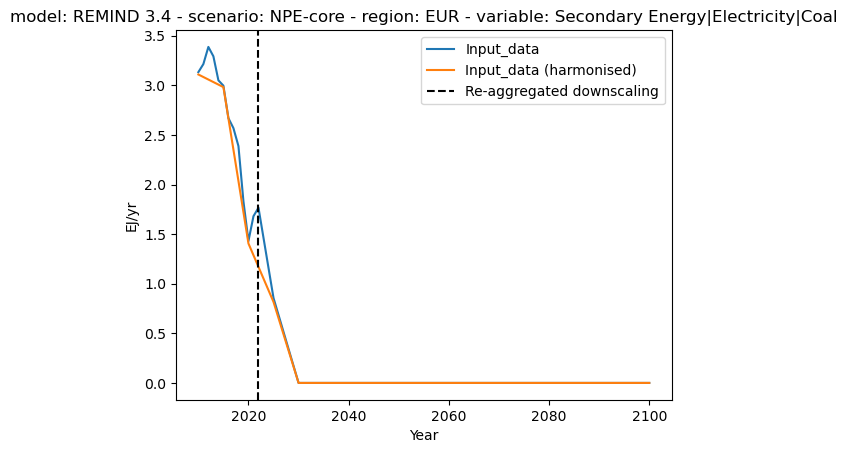

In [26]:
f, ax = plt.subplots()

plot_var = elec('Coal')
plot_reg = 'EUR'

input_data.filter(region=plot_reg,variable=plot_var,scenario='*core*').plot(ax=ax)

# input_data_harm.filter(region=plot_reg,variable=plot_var,scenario='*core*').plot(ax=ax)

dscale_results_agg.filter(region=plot_reg,variable=plot_var,scenario='*core*').plot(ax=ax)
# dscale_results_agg_harmo_input.filter(region=plot_reg,variable=plot_var,scenario='*core*').plot(ax=ax)

ax.axvline(x=2022, color='k',ls='--')

ax.legend(['Input_data','Input_data (harmonised)','Re-aggregated downscaling','Re-aggregated downscaling (harmonised)'])

This shows (very worryingly) that DSCALE is NOT currently enforcing regional consistency –> the country-level results do not add up to the macro-region results! 

In [18]:
change_in_macro_data = (dscale_results_agg.timeseries() / input_data.timeseries()).dropna(how='all').pix.assign(unit='change_in_results_during_dscale')
change_in_macro_data = change_in_macro_data.loc[~ismatch(variable='Price**')]

change_in_macro_data_harmo_input = (dscale_results_agg_harmo_input.timeseries() / input_data_harm.timeseries()).dropna(how='all').pix.assign(unit='change_in_results_during_dscale')
change_in_macro_data_harmo_input = change_in_macro_data_harmo_input.loc[~ismatch(variable='Price**')]

In [33]:
dscale_results

<class 'pyam.core.IamDataFrame'>
Index:
 * model    : REMIND 3.4 (1)
 * scenario : NPE-core (1)
Timeseries data coordinates:
   region   : ABW, AFG, AGO, ALB, ARE, ARG, ARM, ASM, ATG, AUS, ... ZWE (218)
   variable : Capacity Additions|Electricity|Biomass, ... (548)
   unit     : %, EJ/yr, GW, GW/yr, GWh/yr, Index (2020 = 1), ... million vehicles (22)
   year     : 2010, 2015, 2020, 2025, 2030, 2035, 2040, 2045, ... 2100 (19)
Meta indicators:
   exclude (bool) False (1)

In [35]:
len(power_mix_var)

10

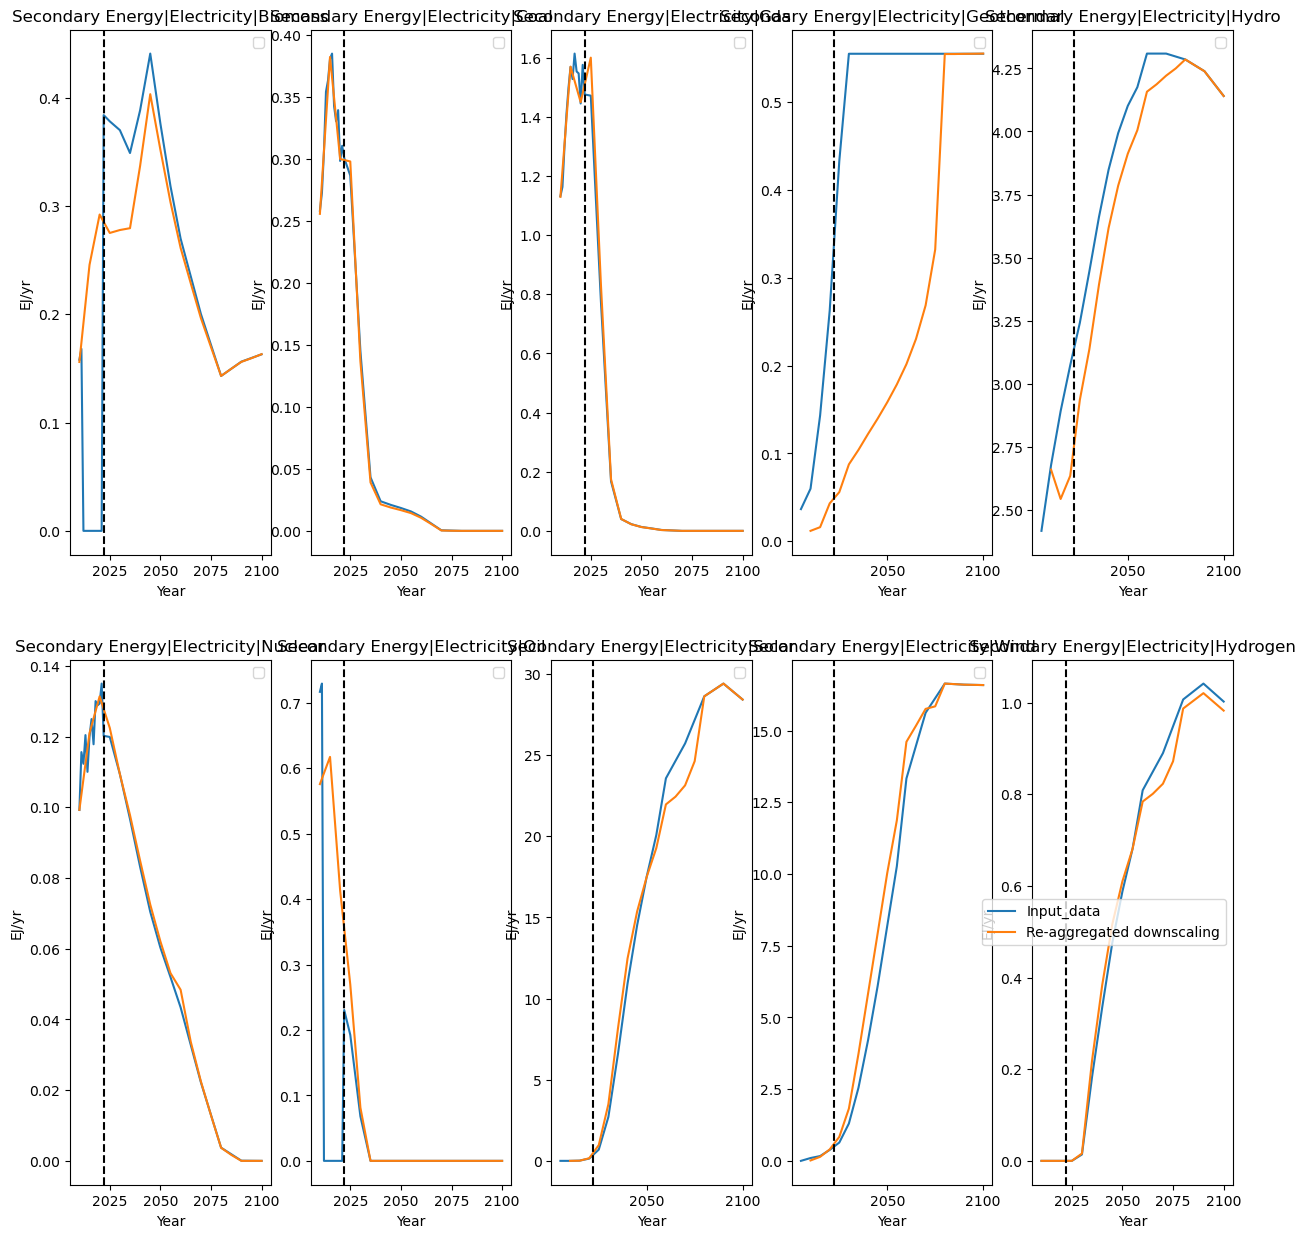

In [36]:
f, axes = plt.subplots(nrows=2,ncols=5,figsize=(15,15))

plot_reg = 'LAM'

for count, ax in enumerate(axes.ravel()[:]):
    # input_data.filter(region=plot_reg,variable=power_mix_var[count],scenario='*core*').plot(ax=ax)
    input_data.filter(region=plot_reg,variable=power_mix_var[count],scenario='*core*').plot(ax=ax)

    # dscale_results_agg.filter(region=plot_reg,variable=power_mix_var[count],scenario='*core*').plot(ax=ax)
    dscale_results_agg.filter(region=plot_reg,variable=power_mix_var[count],scenario='*core*').plot(ax=ax)

    ax.axvline(x=2022, color='k',ls='--')
    ax.set_title(power_mix_var[count])

# ax.legend(['Input_data','Input_data (harmonised)','Re-aggregated downscaling','Re-aggregated downscaling (harmonised)'])
ax.legend(['Input_data','Re-aggregated downscaling',])

In [20]:
change_in_macro_data_harmo_input.loc[ismatch(region='World',variable='Secondary Energy**'),2050].sort_values().replace(0,np.nan).dropna()

model       scenario  region  variable                                             unit                           
REMIND 3.4  NPE-core  World   Secondary Energy|Heat|Biomass                        change_in_results_during_dscale    0.090726
                              Secondary Energy|Heat|Geothermal                     change_in_results_during_dscale    0.137494
                              Secondary Energy|Heat|Coal                           change_in_results_during_dscale    0.156430
                              Secondary Energy|Liquids|Fossil|w/o CCS              change_in_results_during_dscale    0.165582
                              Secondary Energy|Liquids|Fossil                      change_in_results_during_dscale    0.165584
                              Secondary Energy|Electricity|Wind|Offshore           change_in_results_during_dscale    0.197776
                              Secondary Energy|Electricity|Biomass|w/ CCS          change_in_results_during_dscale    0.218

In [39]:
change_in_macro_data.loc[ismatch(region='World',variable='Secondary Energy**'),2030]

model                  scenario            region  variable                                      unit                           
REMIND-MAgPIE 3.3-4.8  NPE-core            World   Secondary Energy                              change_in_results_during_dscale    0.252047
                                                   Secondary Energy|Electricity                  change_in_results_during_dscale    0.965706
                                                   Secondary Energy|Electricity|Biomass          change_in_results_during_dscale    0.807728
                                                   Secondary Energy|Electricity|Biomass|w/ CCS   change_in_results_during_dscale    0.385356
                                                   Secondary Energy|Electricity|Biomass|w/o CCS  change_in_results_during_dscale    0.307883
                                                                                                                                      ...   
                       NP

In [32]:
change_in_macro_data.loc[ismatch(variable=elec('*')),2030].median()

0.9145433109919129

In [33]:
change_in_macro_data_harmo_input.loc[ismatch(variable=elec('*')),2030].median()

0.9996824992093576

## Coal and gas in power sector

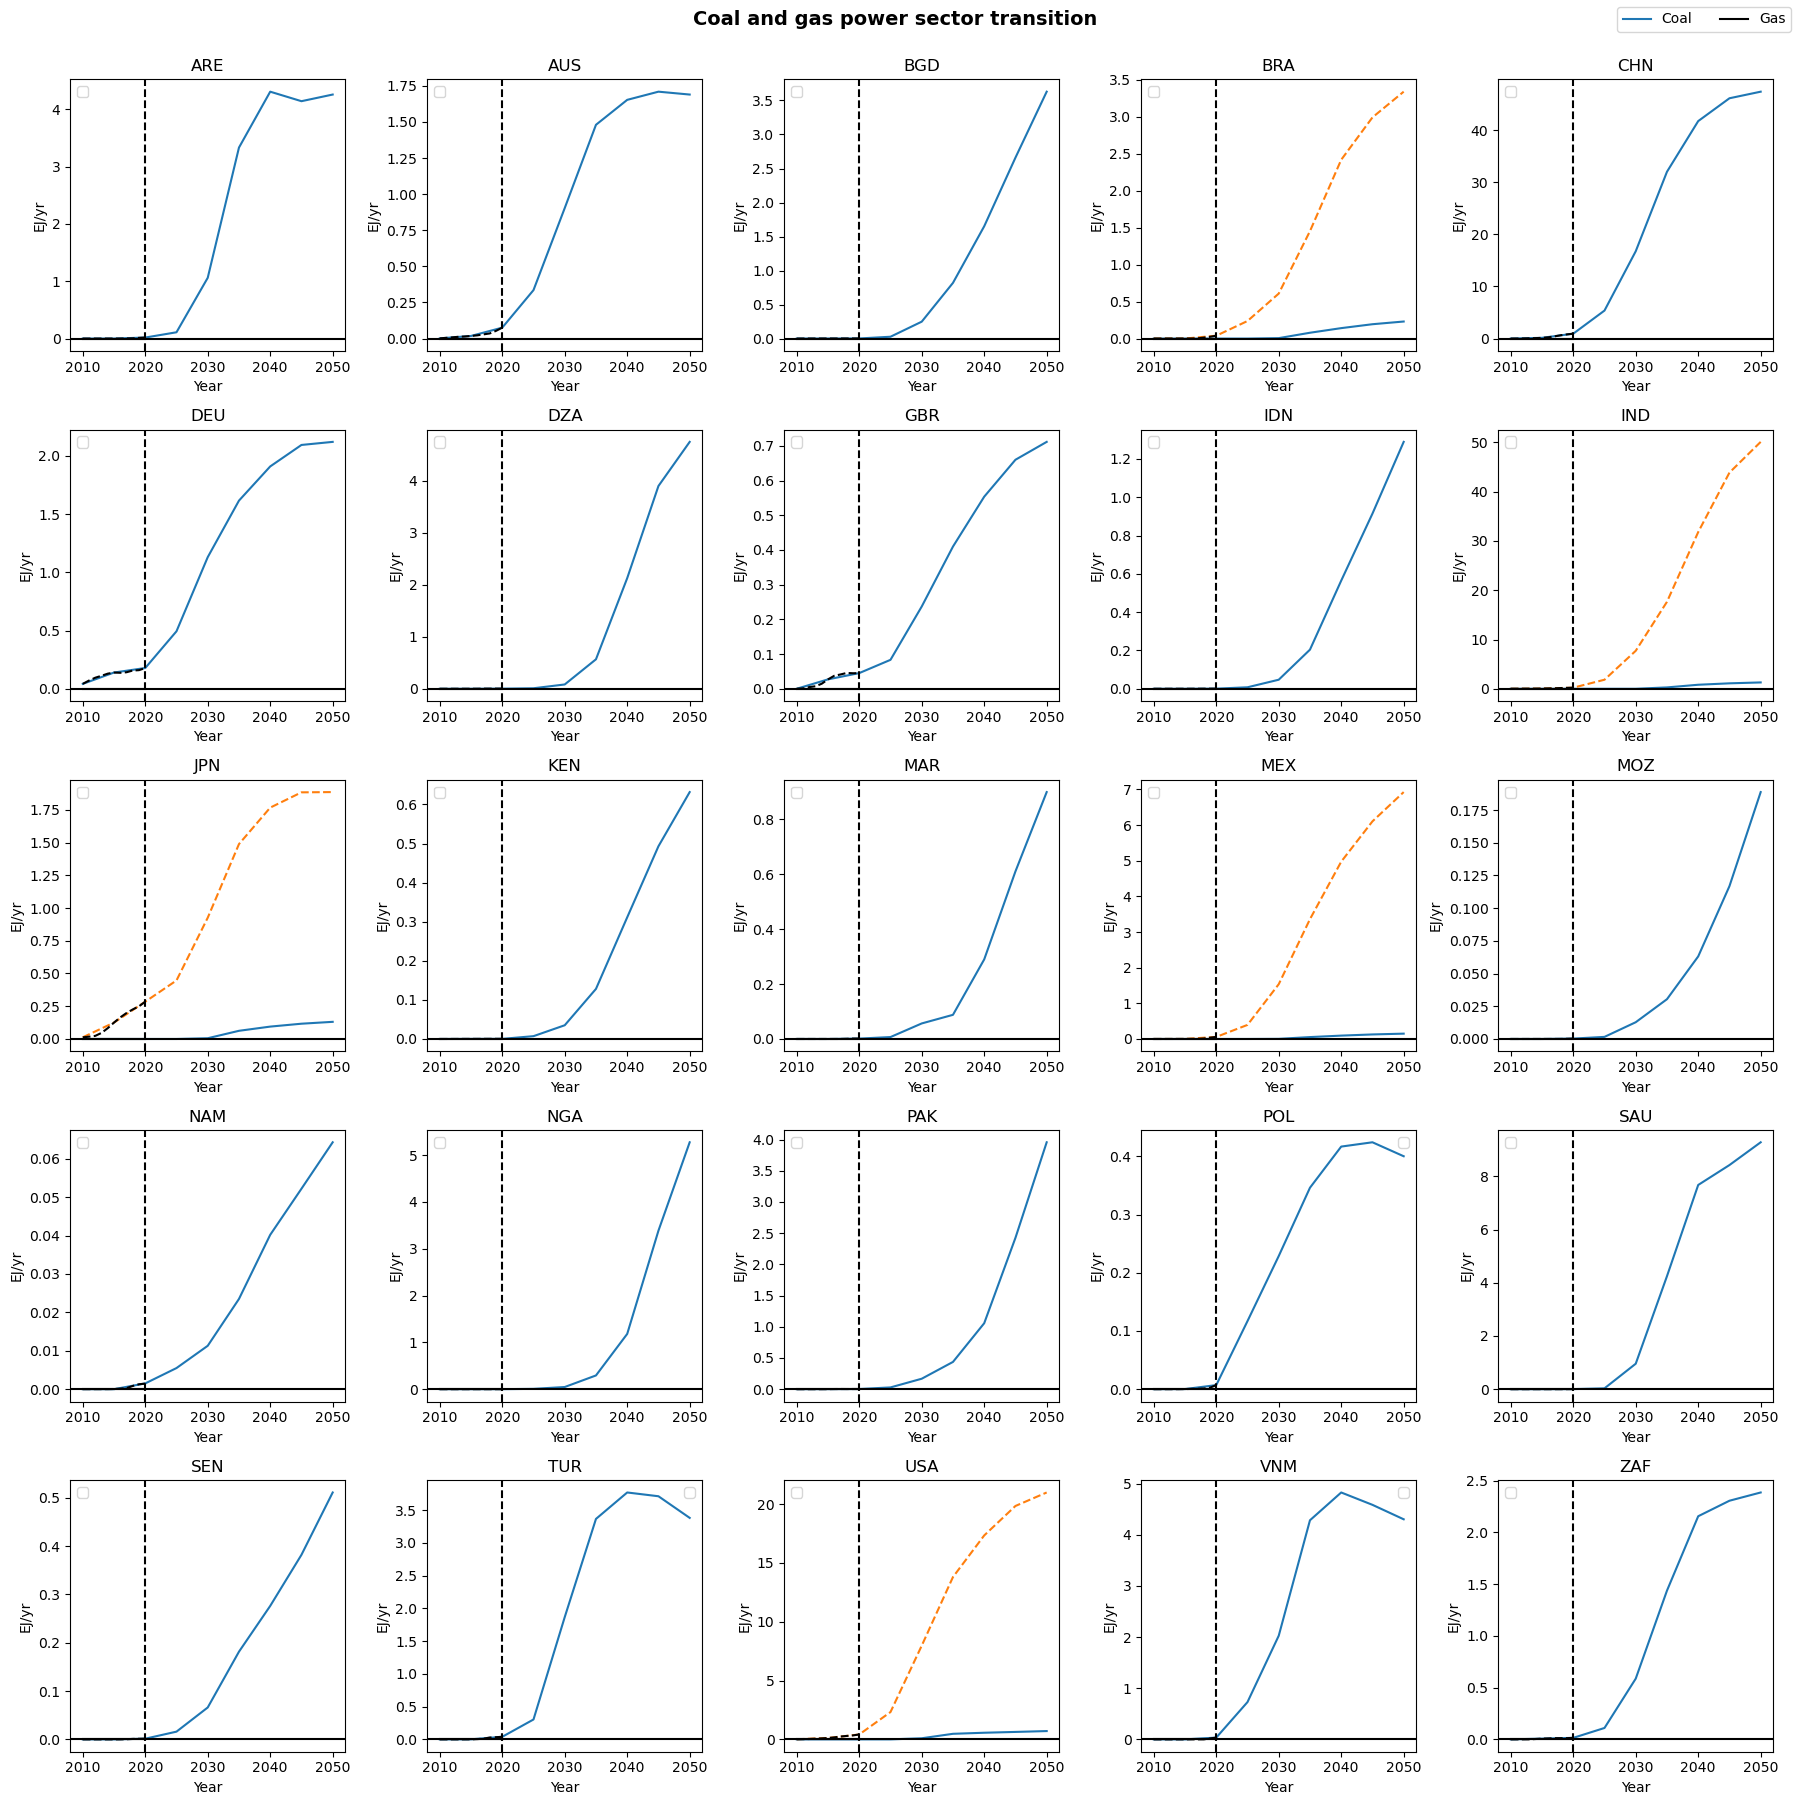

In [41]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
wns_vars = [elec("Solar"),elec('Hydrogen')]

for count, ax in enumerate(axes.ravel()[:]):
    dscale_results.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=wns_vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    hist_data_iea.filter(region=IKEA_ISOS[count],variable=wns_vars,year=range(2010,2021)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2020,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle('Coal and gas power sector transition',fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

## Electricity mix

<Axes: title={'center': 'model: IEA scenario: Historic data region: TUR'}, xlabel='Year', ylabel='EJ/yr'>

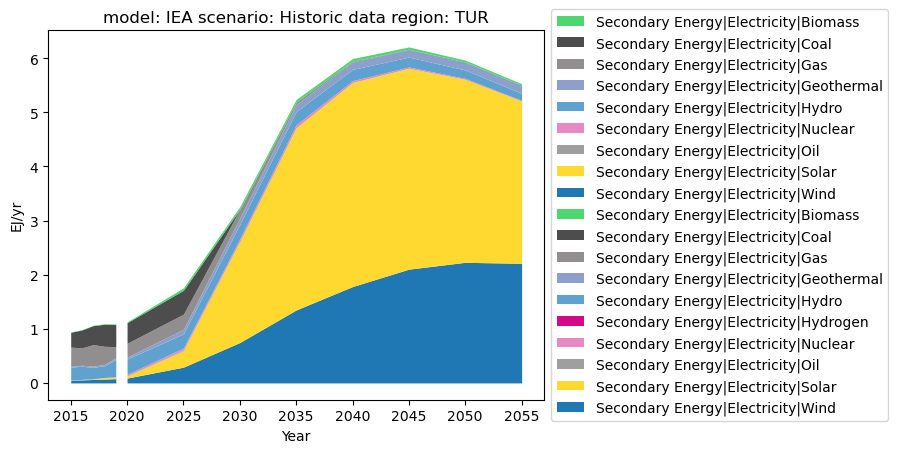

In [64]:
country = "TUR"
dscale_results.filter(
    scenario='NPE-core',
    region=country, 
    variable=power_mix_var,
    year = year_proj
).plot.stack()

hist_data_iea.filter(
    region=country, 
    variable=power_mix_var,
    year=[2015, 2016, 2017, 2018, 2019]
).plot.stack(ax=plt.gca())

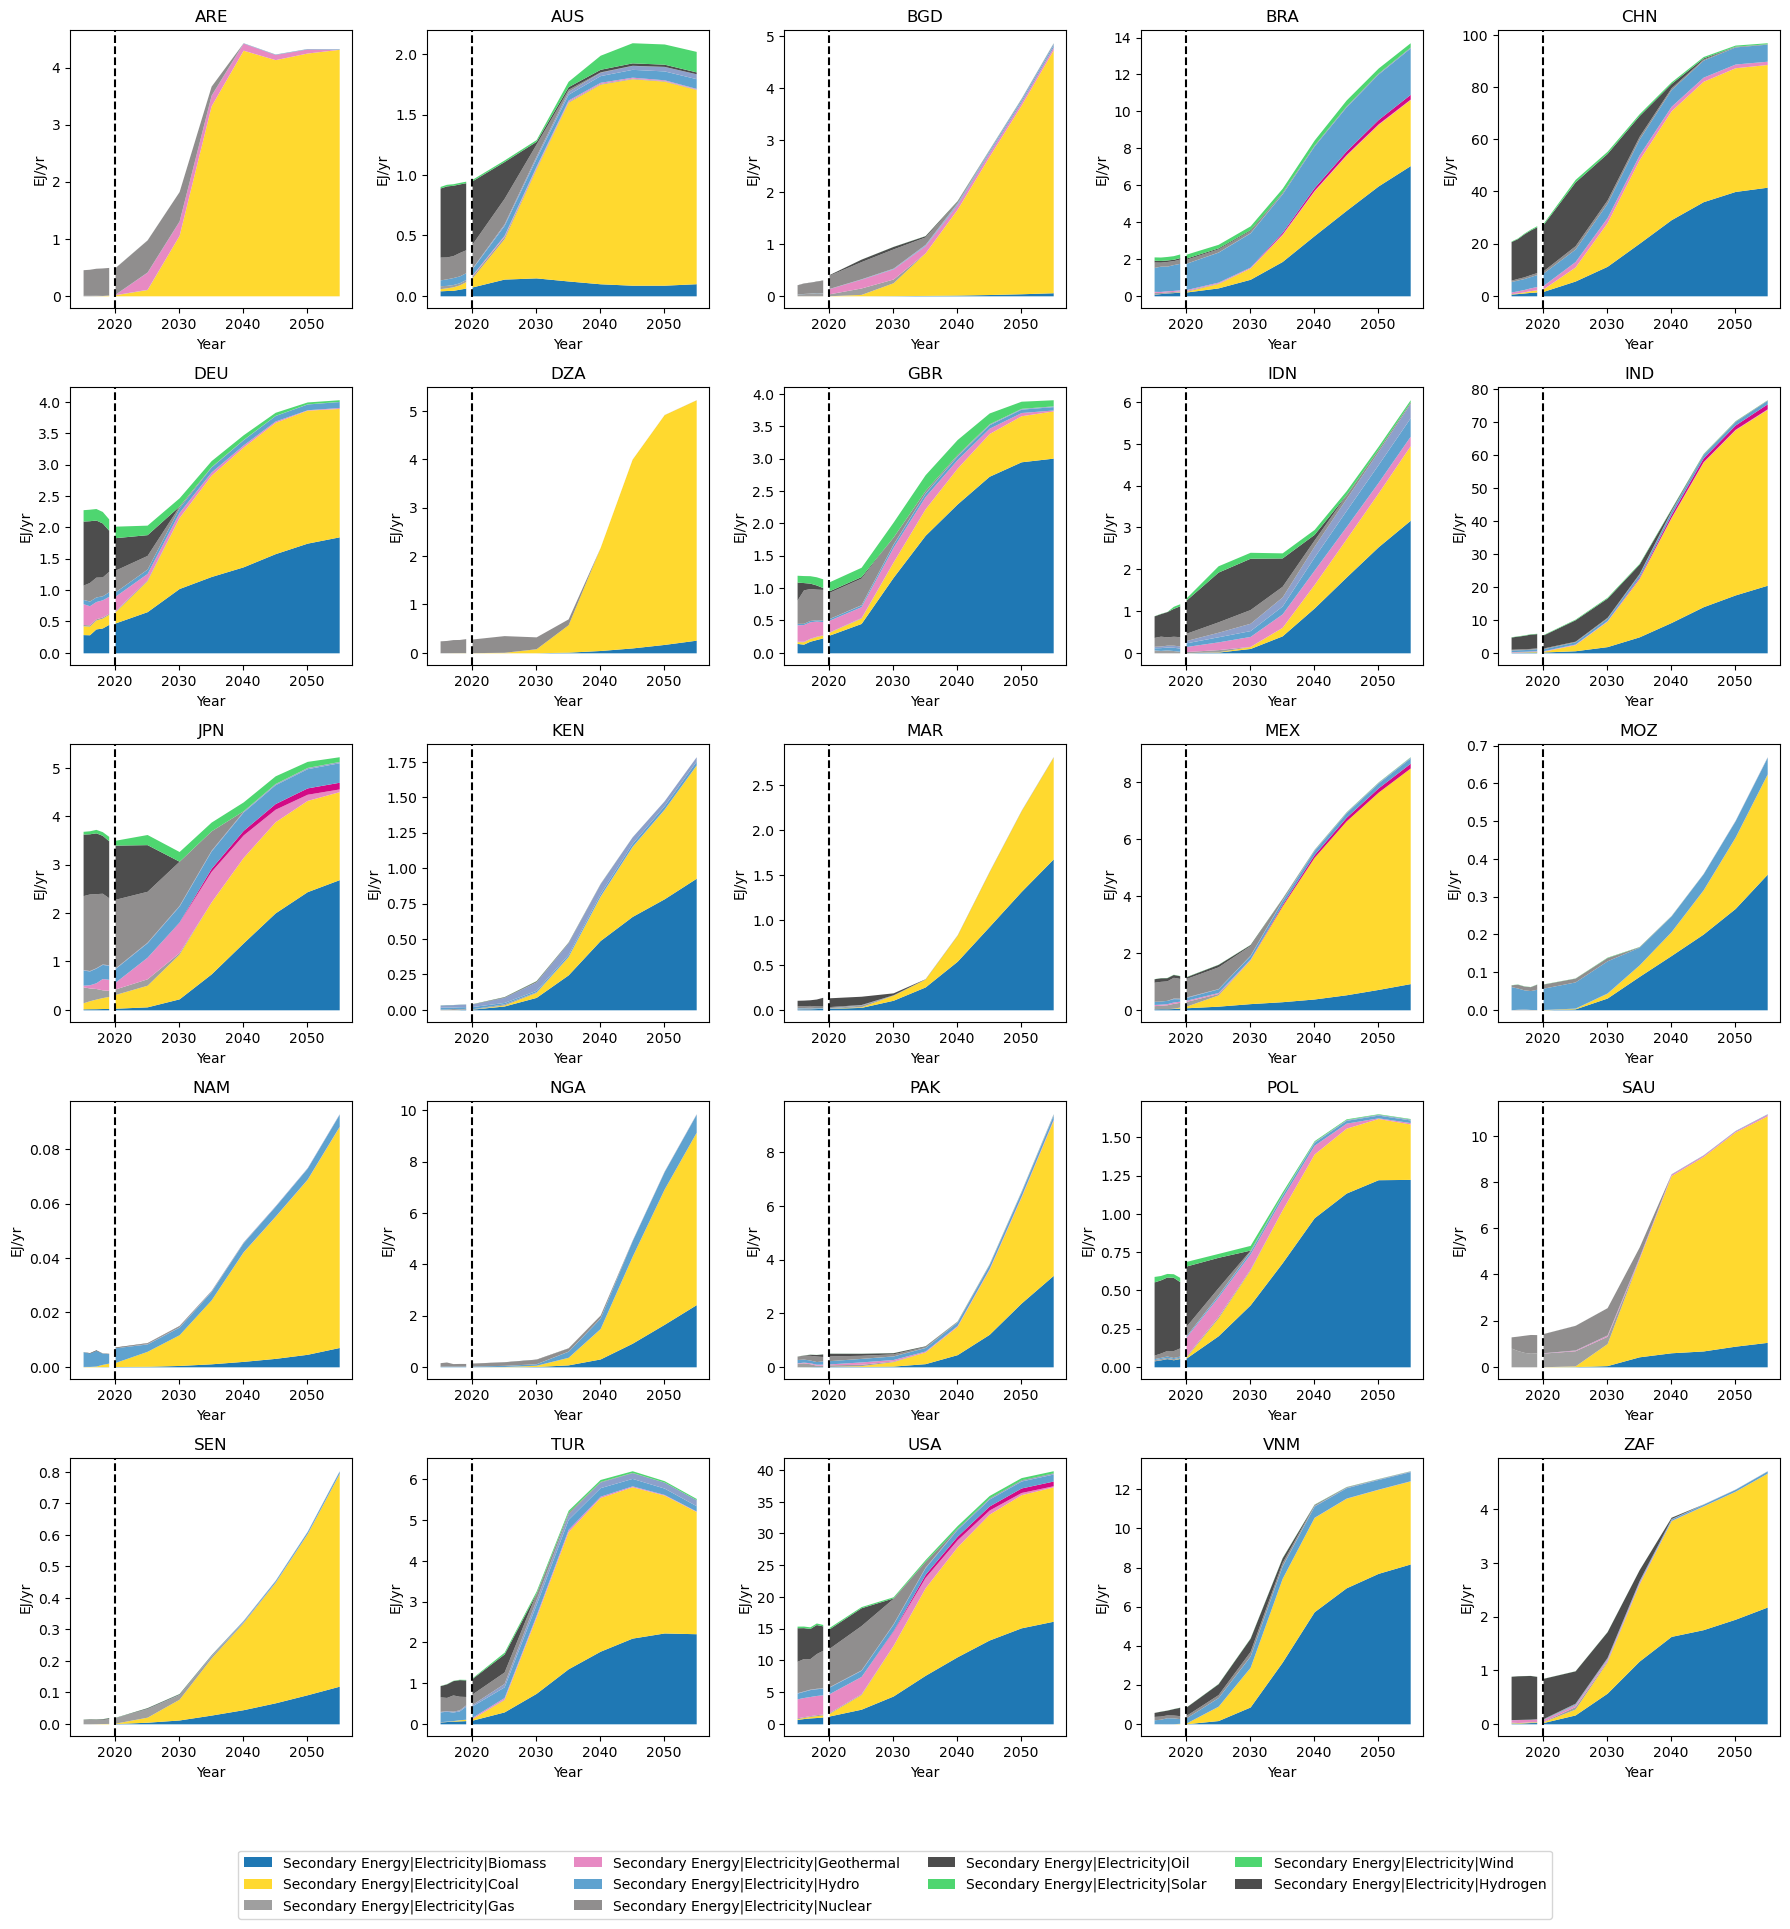

In [45]:
year_proj = [2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
 2055,
#  2060,
#  2065,
#  2070,
#  2075,
#  2080,
#  2085,
#  2090,
#  2095,
#  2100]
]
f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=power_mix_var,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=power_mix_var,
        year=[2015, 2016, 2017, 2018, 2019]
    ).plot.stack(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

# f.suptitle('Power sector mix',fontsize=14,fontweight='bold')
f.legend(power_mix_var,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

In [29]:
primary_mix_var = [
    'Primary Energy|Biomass',
    'Primary Energy|Coal',
    'Primary Energy|Gas',
    'Primary Energy|Geothermal',
    'Primary Energy|Hydro',
    'Primary Energy|Nuclear',
    'Primary Energy|Oil',
    'Primary Energy|Solar',
    'Primary Energy|Wind']

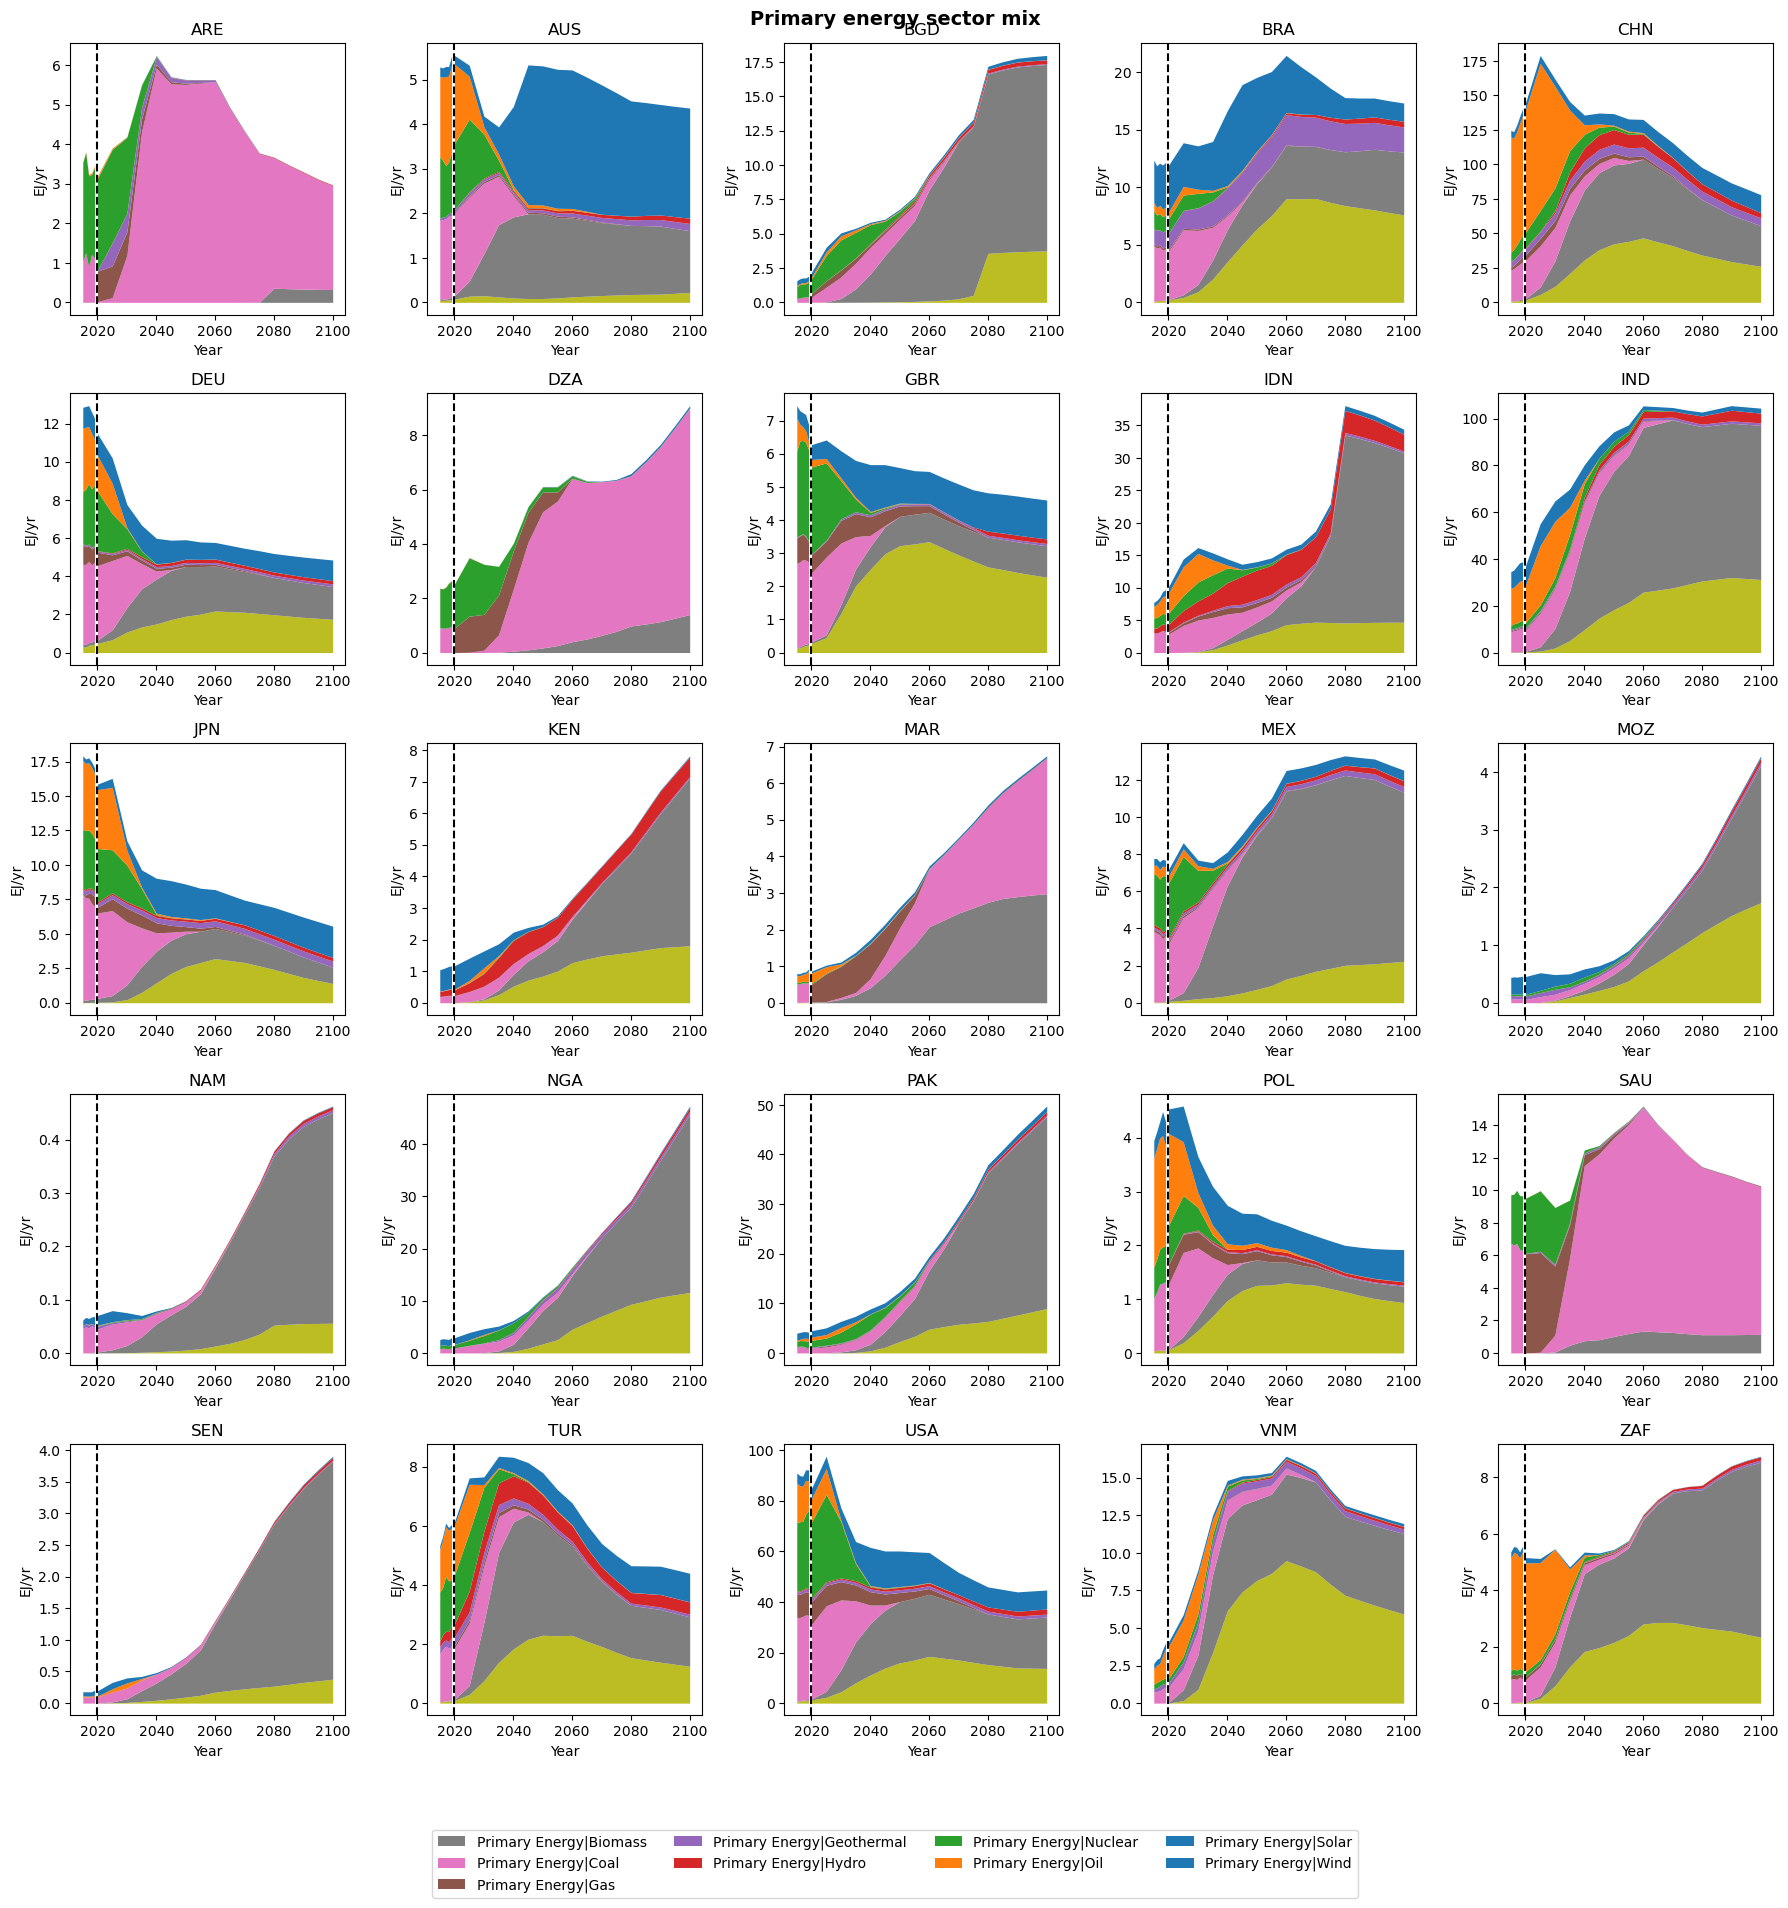

In [32]:
year_proj = [2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
 2055,
 2060,
 2065,
 2070,
 2075,
 2080,
 2085,
 2090,
 2095,
 2100]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=primary_mix_var,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=primary_mix_var,
        year=[2015, 2016, 2017, 2018, 2019]
    ).plot.stack(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Primary energy sector mix',fontsize=14,fontweight='bold')
f.legend(primary_mix_var,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

## Comparison with NPE Siamese

In [156]:
from matplotlib.patches import Patch

tech_handles = [
    Patch(
        facecolor=color_map[v],
        edgecolor="k",
        label=v.split('|')[-1]
    )
    for v in power_mix_var
]

scenario_handles = [
    Patch(
        facecolor="white",
        edgecolor="k",
        hatch="",
        label="NPE-core"
    ),
    Patch(
        facecolor="white",
        edgecolor="k",
        hatch="//",
        label="Deep"
    )
]


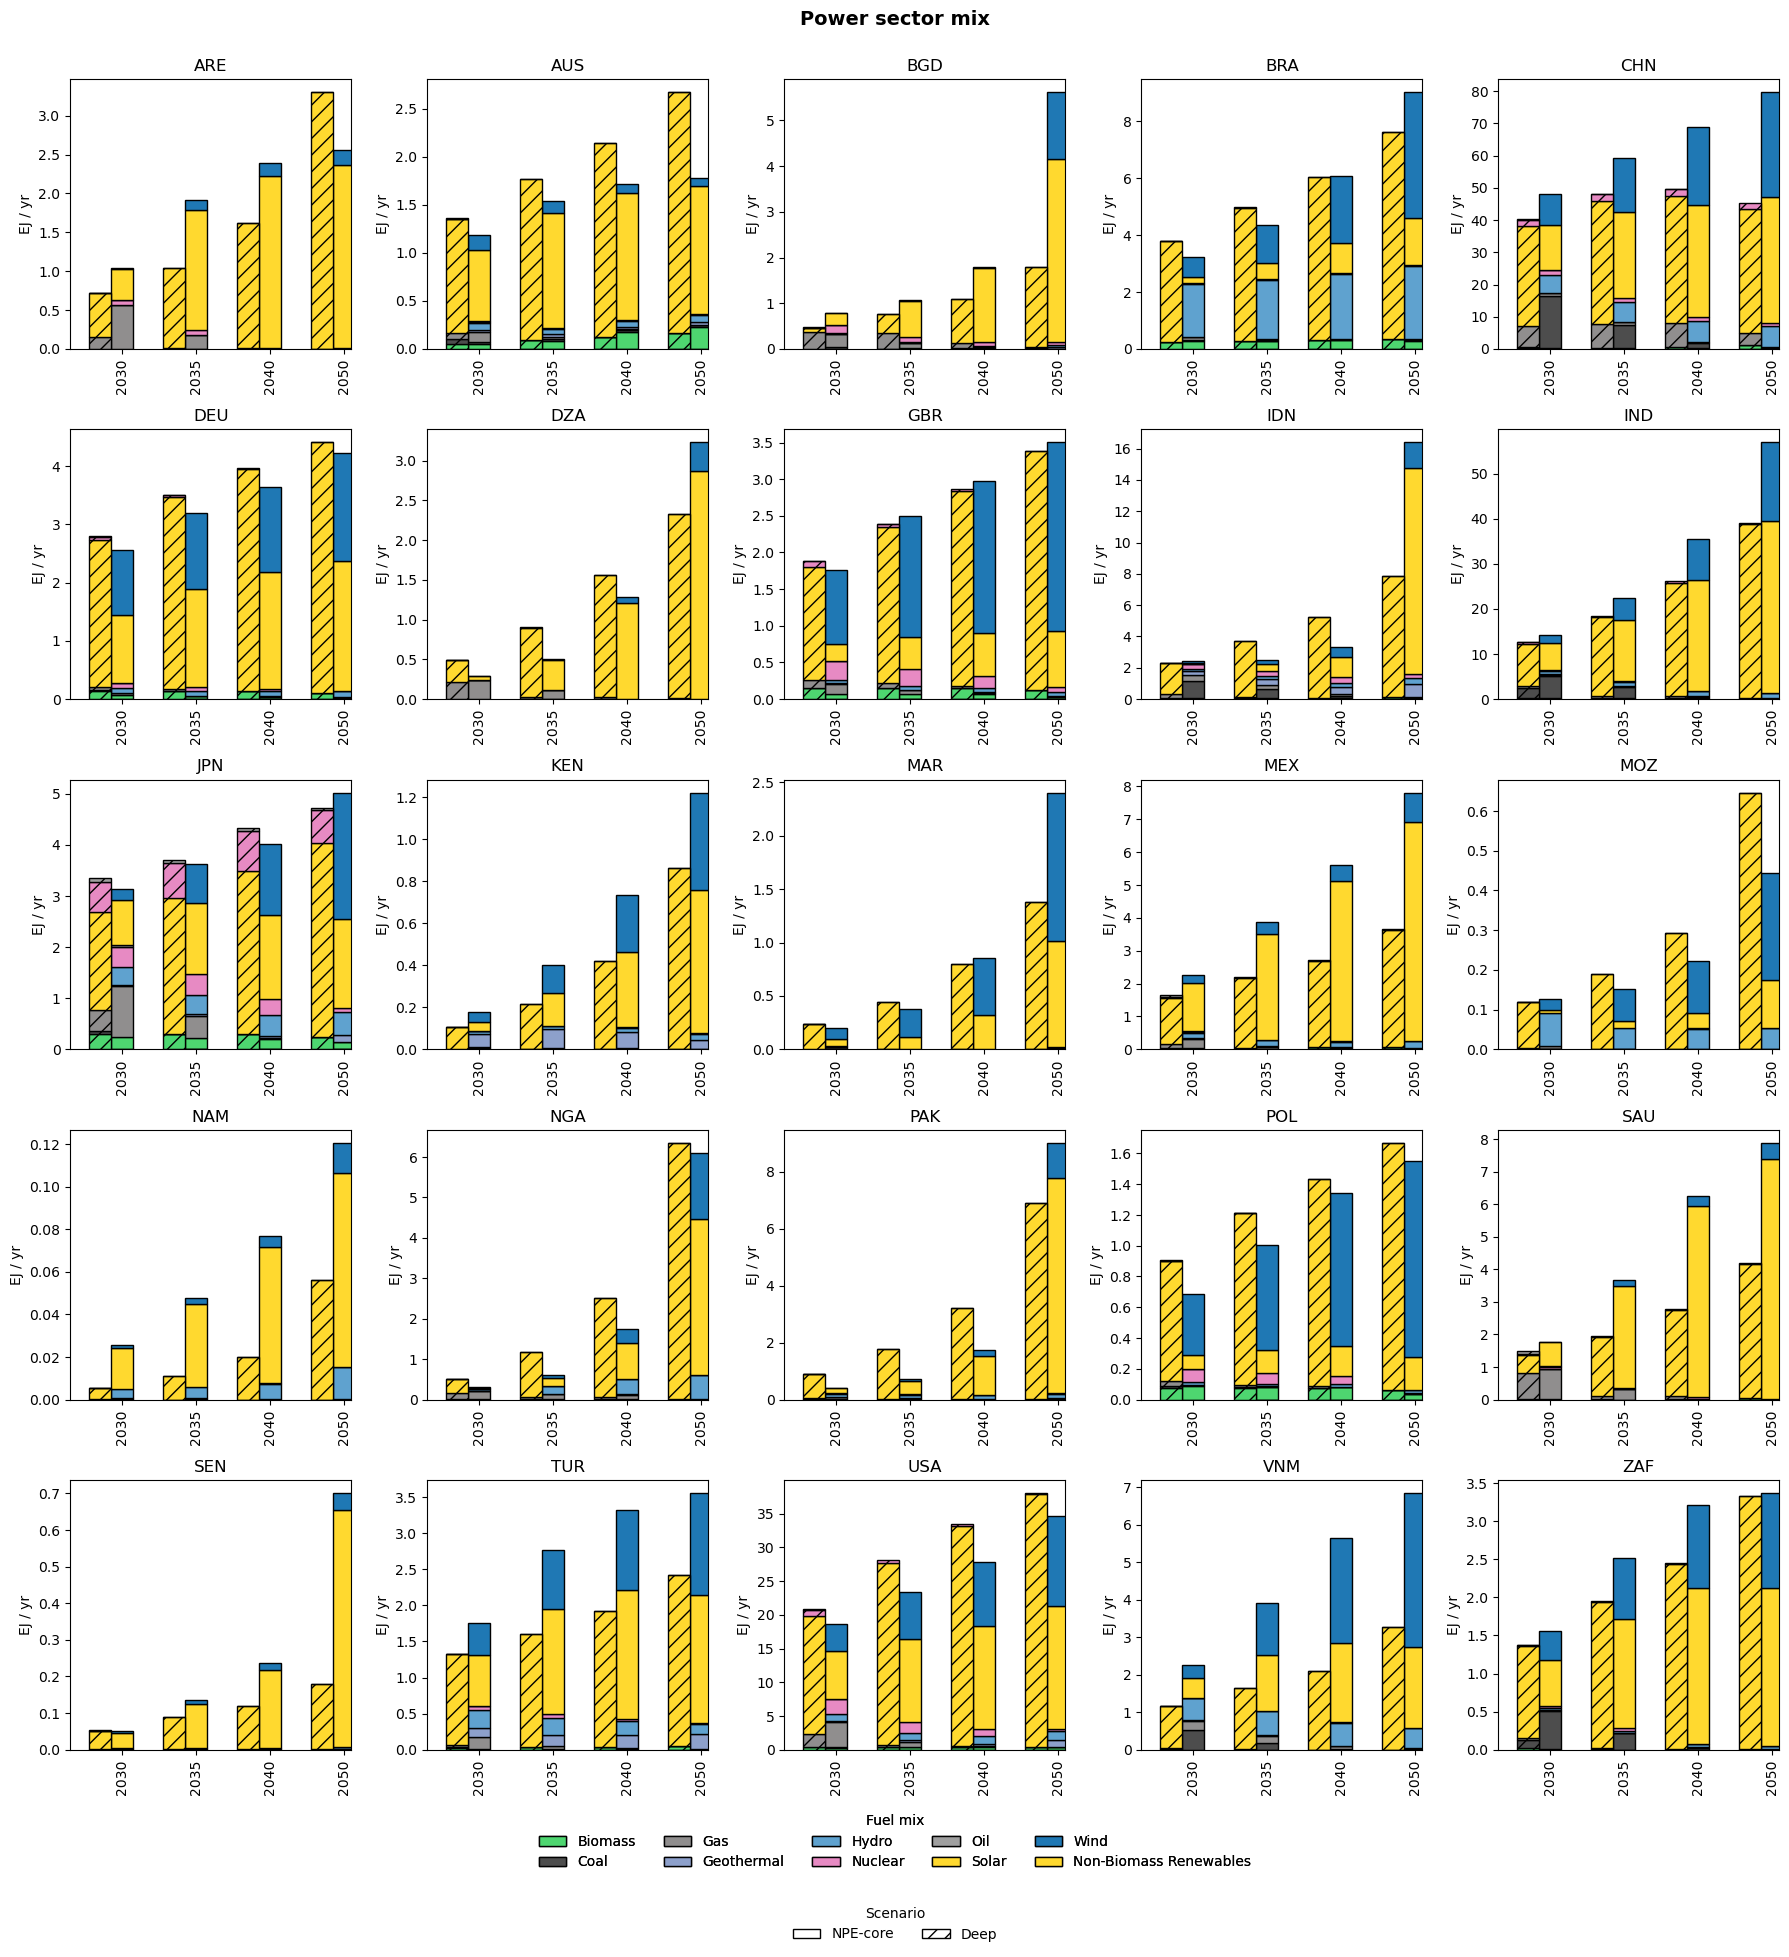

In [165]:


f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        year = [2030,2035,2040,2050],
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=power_mix_var[:-1]
    ).plot.bar(stacked=True, ax=ax, width=0.3, edgecolor="k")

    npe_siamese.filter(
        year = [2030,2035,2040,2050], 
        variable = power_mix_var, 
        region = IKEA_ISOS[count], 
        scenario = "*Deep*"
    ).plot.bar(stacked=True, ax = ax, position=1.5, width=0.3, hatch="//", edgecolor="k")

    # ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.set_xlabel("")
    ax.legend().remove()
    # ax.set_xlim(2020,2060)

# LEGEND
# Technology legend
leg1 = f.legend(
    handles=tech_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
    title="Fuel mix"
)

# Scenario legend
leg2 = f.legend(
    handles=scenario_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    title="Scenario"
)

# Ensure both legends stay visible
f.add_artist(leg1)


f.suptitle('Power sector mix',fontsize=14,fontweight='bold', y =1)
# f.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

# f.legend()
plt.tight_layout()

In [138]:
dscale_results.filter(variable="*Non-CO2*").variable

['Emissions|Total Non-CO2', 'Statistical Difference|Emissions|Total Non-CO2']

In [ ]:
## Variable to check for sector
# Proiority
"Primary Energy*"
"Final Energy|Transportation*"
# next to the list
"Final Energy|Industry*"
"Final Energy|Residential and Commercial*"

In [139]:
power_mix_var

['Secondary Energy|Electricity|Biomass',
 'Secondary Energy|Electricity|Coal',
 'Secondary Energy|Electricity|Gas',
 'Secondary Energy|Electricity|Geothermal',
 'Secondary Energy|Electricity|Hydro',
 'Secondary Energy|Electricity|Nuclear',
 'Secondary Energy|Electricity|Oil',
 'Secondary Energy|Electricity|Solar',
 'Secondary Energy|Electricity|Wind',
 'Secondary Energy|Electricity|Non-Biomass Renewables']

In [ ]:
# Compute shares
for var in power_mix_var:
    dscale_results.divide(
        var, 
        'Secondary Energy|Electricity', 
        var+"|share", 
        unit= "%",
        append=True, 
    )


## Phase out year

In [190]:
def phaseout_metric(x, threshold):
    x_values = x[x < threshold]
    return x_values.index[0] if len(x_values) > 0 else "Post-2050"

#Get yearly data
def yearly_data(df):
    df_copy = df.copy()
    df = pd.DataFrame(columns=range(2019,2071,1))
    for i in range(len(df_copy.columns)):
        df[df_copy.columns[i]] = df_copy[df_copy.columns[i]]
    
    df = df.astype("float").interpolate(method="linear",axis=1)
        
    return df

#Phaseout date based on when electricity share is <2.5% total electricity
df_electricity_share = yearly_data(dscale_results.filter(variable = "*share").timeseries())

phaseout_electricity_share = df_electricity_share.loc[isin(variable=["Secondary Energy|Electricity|Coal|share",
                                                            "Secondary Energy|Electricity|Gas|share"],region=IKEA_ISOS)].apply(
        lambda x: phaseout_metric(x, 0.025),
        axis = 1
    ).sort_index(level="variable")

In [ ]:
pd.DataFrame(phaseout_electricity_share).unstack("variable")

0  \
variable                        Secondary Energy|Electricity|Coal|share   
model      scenario region unit                                           
REMIND 3.4 NPE-core ARE                                            2020   
                    AUS                                            2030   
                    BGD                                            2034   
                    BRA                                            2023   
                    CHN                                            2040   
                    DEU                                            2030   
                    DZA                                            2020   
                    GBR                                            2020   
                    IDN                                            2041   
                    IND                                            2040   
                    JPN                                            2030   
                    KEN                                            2031   
                    MAR                                            2034   
                    MEX                                            2029   
                    MOZ                                            2020   
                    NAM                                            2021   
                    NGA                                            2034   
                    PAK                                            2034   
                    POL                                            2030   
                    SAU                                            2020   
                    SEN                                            2029   
                    TUR                                            2030   
                    USA                                            2030   
                    VNM                                            2038   
                    ZAF                                            2039   

                                                                        
variable                        Secondary Energy|Electricity|Gas|share  
model      scenario region unit                                         
REMIND 3.4 NPE-core ARE                                           2039  
                    AUS                                           2035  
                    BGD                                           2040  
                    BRA                                           2032  
                    CHN                                           2028  
                    DEU                                           2030  
                    DZA                                           2040  
                    GBR                                           2035  
                    IDN                                           2044  
                    IND                                           2025  
                    JPN                                           2040  
                    KEN                                           2020  
                    MAR                                           2031  
                    MEX                                           2035  
                    MOZ                                           2034  
                    NAM                                           2020  
                    NGA                                           2044  
                    PAK                                           2037  
                    POL                                           2029  
                    SAU                                           2039  
                    SEN                                           2024  
                    TUR                                           2035  
                    USA                                           2037  
                    VNM                                           2039 

In [184]:
dscale_results.filter(variable = "*Gas|share", region = IKEA_ISOS).timeseries() < 0.025

2010  \
model      scenario region variable                               unit          
REMIND 3.4 NPE-core ARE    Secondary Energy|Electricity|Gas|share       False   
                    AUS    Secondary Energy|Electricity|Gas|share       False   
                    BGD    Secondary Energy|Electricity|Gas|share       False   
                    BRA    Secondary Energy|Electricity|Gas|share       False   
                    CHN    Secondary Energy|Electricity|Gas|share        True   
                    DEU    Secondary Energy|Electricity|Gas|share       False   
                    DZA    Secondary Energy|Electricity|Gas|share       False   
                    GBR    Secondary Energy|Electricity|Gas|share       False   
                    IDN    Secondary Energy|Electricity|Gas|share       False   
                    IND    Secondary Energy|Electricity|Gas|share       False   
                    JPN    Secondary Energy|Electricity|Gas|share       False   
                    KEN    Secondary Energy|Electricity|Gas|share        True   
                    MAR    Secondary Energy|Electricity|Gas|share       False   
                    MEX    Secondary Energy|Electricity|Gas|share       False   
                    MOZ    Secondary Energy|Electricity|Gas|share        True   
                    NAM    Secondary Energy|Electricity|Gas|share        True   
                    NGA    Secondary Energy|Electricity|Gas|share       False   
                    PAK    Secondary Energy|Electricity|Gas|share       False   
                    POL    Secondary Energy|Electricity|Gas|share        True   
                    SAU    Secondary Energy|Electricity|Gas|share       False   
                    SEN    Secondary Energy|Electricity|Gas|share       False   
                    TUR    Secondary Energy|Electricity|Gas|share       False   
                    USA    Secondary Energy|Electricity|Gas|share       False   
                    VNM    Secondary Energy|Electricity|Gas|share       False   
                    ZAF    Secondary Energy|Electricity|Gas|share        True   

                                                                         2015  \
model      scenario region variable                               unit          
REMIND 3.4 NPE-core ARE    Secondary Energy|Electricity|Gas|share       False   
                    AUS    Secondary Energy|Electricity|Gas|share       False   
                    BGD    Secondary Energy|Electricity|Gas|share       False   
                    BRA    Secondary Energy|Electricity|Gas|share       False   
                    CHN    Secondary Energy|Electricity|Gas|share       False   
                    DEU    Secondary Energy|Electricity|Gas|share       False   
                    DZA    Secondary Energy|Electricity|Gas|share       False   
                    GBR    Secondary Energy|Electricity|Gas|share       False   
                    IDN    Secondary Energy|Electricity|Gas|share       False   
                    IND    Secondary Energy|Electricity|Gas|share       False   
                    JPN    Secondary Energy|Electricity|Gas|share       False   
                    KEN    Secondary Energy|Electricity|Gas|share        True   
                    MAR    Secondary Energy|Electricity|Gas|share       False   
                    MEX    Secondary Energy|Electricity|Gas|share       False   
                    MOZ    Secondary Energy|Electricity|Gas|share       False   
                    NAM    Secondary Energy|Electricity|Gas|share        True   
                    NGA    Secondary Energy|Electricity|Gas|share       False   
                    PAK    Secondary Energy|Electricity|Gas|share       False   
                    POL    Secondary Energy|Electricity|Gas|share       False   
                    SAU    Secondary Energy|Electricity|Gas|share       False   
                    SEN    Secondary Energy|Electricity|Gas|share       False   
                    TU

## Electricity emissions - we don't have them yet